
# 📊 Unsupervised Learning: Clustering Analysis for RAG Evaluation

## Document & Query Clustering Analysis
**Author:** Abdel | **Date:** December 2024

---

### 🎯 Objectives
- **Advanced Document Clustering**: Leverage **Qdrant Embeddings** (with TF-IDF fallback) to group research papers.
- **Hierarchy Analysis**: Visualize topic relationships with **Dendrograms**.
- **Method Comparison**: Quantitatively compare **K-Means vs. Hierarchical Clustering**.
- **Automated Insights**: Extract semantic meaning (keywords/topics) for each cluster.
- **Visualization**: High-quality **t-SNE** 2D projection of the research manifold.


## 1️⃣ Setup & Configuration

In [29]:

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pathlib import Path

# Clustering & ML imports
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
from qdrant_client import QdrantClient

# Configure plots
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

# Load environment variables
load_dotenv('../backend/.env')
print('✅ Environment loaded!')


✅ Environment loaded!


## 2️⃣ Data Loading

In [30]:

# Paths
DATASET_PATH = Path('../backend/data/arxiv/evaluation_dataset_improved.json')
RESULTS_PATH = Path('../evaluation_results.json')

# Load evaluation dataset
if DATASET_PATH.exists():
    with open(DATASET_PATH, 'r') as f:
        dataset = json.load(f)
    print(f"📄 Dataset loaded: {dataset['dataset_info']['num_papers']} papers")
else:
    print(f"⚠️ Dataset not found at {DATASET_PATH}")
    dataset = {'test_cases': []}

# Load results
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'r') as f:
        results = json.load(f)
    print(f"📊 Results loaded: {len(results.get('test_cases', []))} test cases")
else:
    results = {}


📄 Dataset loaded: 159 papers
📊 Results loaded: 5 test cases


## 3️⃣ Data Preprocessing & Embedding Generation

In [31]:
# Extract abstracts and metadata
papers_data = []
abstracts = []

for tc in dataset.get('test_cases', []):
    abstract = tc.get('paper_abstract', '')
    if abstract:
        abstracts.append(abstract)
        papers_data.append({
            'paper_id': tc.get('paper_id', ''),
            'title': tc.get('paper_title', ''),
            'primary_category': tc.get('primary_category', 'Unknown'),
            'categories': ', '.join(tc.get('categories', [])),
            'paper_abstract': abstract  # <--- CRITICAL: This was missing before
        })

df_papers = pd.DataFrame(papers_data)
print(f"📚 Processed {len(df_papers)} papers.")
df_papers['main_category'] = df_papers['primary_category'].apply(
    lambda x: x.split('.')[0] if '.' in str(x) else str(x)
)
print(f"📊 Category Distribution:")
print(df_papers['main_category'].value_counts())


# --- Embedding Strategy ---
# Try to fetch from Qdrant first, fallback to TF-IDF
embeddings = []
paper_ids = df_papers['paper_id'].tolist()
use_qdrant = False
qdrant_embeddings_map = {}

try:
    qdrant_url = os.getenv("QDRANT_URL", "http://localhost:6333")
    qdrant_key = os.getenv("QDRANT_API_KEY")
    
    print(f"🔌 Connecting to Qdrant at {qdrant_url}...")
    client = QdrantClient(url=qdrant_url, api_key=qdrant_key)
    
    # Check if collection exists
    collections = client.get_collections()
    collection_name = "document_chunks"
    
    if any(c.name == collection_name for c in collections.collections):
        print(f"✅ Found collection: {collection_name}")
        
        # Scroll points to aggregate vectors by document_id
        # Note: In a large system, we might optimize this. For 159 papers, scrolling is fine.
        all_points = []
        offset = None
        while True:
            points, offset = client.scroll(
                collection_name=collection_name,
                limit=100,
                with_payload=True,
                with_vectors=True,
                scroll_filter=None,
                offset=offset
            )
            all_points.extend(points)
            if offset is None:
                break
        
        print(f"📥 Fetched {len(all_points)} chunks from Qdrant.")
        
        # Group vectors by document_id
        doc_vectors = {}
        for p in all_points:
            doc_id = p.payload.get('document_id')
            vector = p.vector
            if doc_id and vector:
                if doc_id not in doc_vectors:
                    doc_vectors[doc_id] = []
                doc_vectors[doc_id].append(vector)
        
        # Compute mean vector per document
        for doc_id, vectors in doc_vectors.items():
            if vectors:
                qdrant_embeddings_map[doc_id] = np.mean(vectors, axis=0)
        
        print(f"🧩 Aggregated vectors for {len(qdrant_embeddings_map)} documents.")
        use_qdrant = True
        
    else:
        print(f"⚠️ Collection {collection_name} not found.")

except Exception as e:
    print(f"⚠️ Qdrant Error: {e}")

# Align embeddings with dataset papers
final_embeddings = []
missing_count = 0

if use_qdrant:
    # Check dimension from first vector
    first_vec = next(iter(qdrant_embeddings_map.values()))
    embedding_dim = len(first_vec)
    
    for pid in paper_ids:
        if pid in qdrant_embeddings_map:
            final_embeddings.append(qdrant_embeddings_map[pid])
        else:
            missing_count += 1
            final_embeddings.append(np.zeros(embedding_dim)) # Zero placeholder for now
    
    if missing_count > len(paper_ids) * 0.5:
        print(f"⚠️ Too many missing Qdrant vectors ({missing_count}/{len(paper_ids)}). Reverting to TF-IDF.")
        use_qdrant = False
    else:
        embeddings = np.array(final_embeddings)
        print(f"✅ Successfully mapped Qdrant embeddings for {len(paper_ids) - missing_count} papers.")

if not use_qdrant:
    print("ℹ️ Using TF-IDF for embeddings (Fallback/Primary)")
    vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
    embeddings = vectorizer.fit_transform(abstracts).toarray()

print(f"✅ Final Embeddings shape: {embeddings.shape}")

📚 Processed 159 papers.
📊 Category Distribution:
main_category
cs      134
stat     25
Name: count, dtype: int64
🔌 Connecting to Qdrant at http://localhost:6333...
✅ Found collection: document_chunks


/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_57913/514113313.py:38: UserWarning: Api key is used with an insecure connection.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_key)
/var/folders/8c/dff_cs955gl64q4rx2r115xh0000gn/T/ipykernel_57913/514113313.py:38: UserWarning: Qdrant client version 1.16.1 is incompatible with server version 1.7.0. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_key)


📥 Fetched 957 chunks from Qdrant.
🧩 Aggregated vectors for 158 documents.
✅ Successfully mapped Qdrant embeddings for 158 papers.
✅ Final Embeddings shape: (159, 1536)


## 4️⃣ Clustering Analysis

### 4.1 Determine Optimal K (Elbow Method)

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

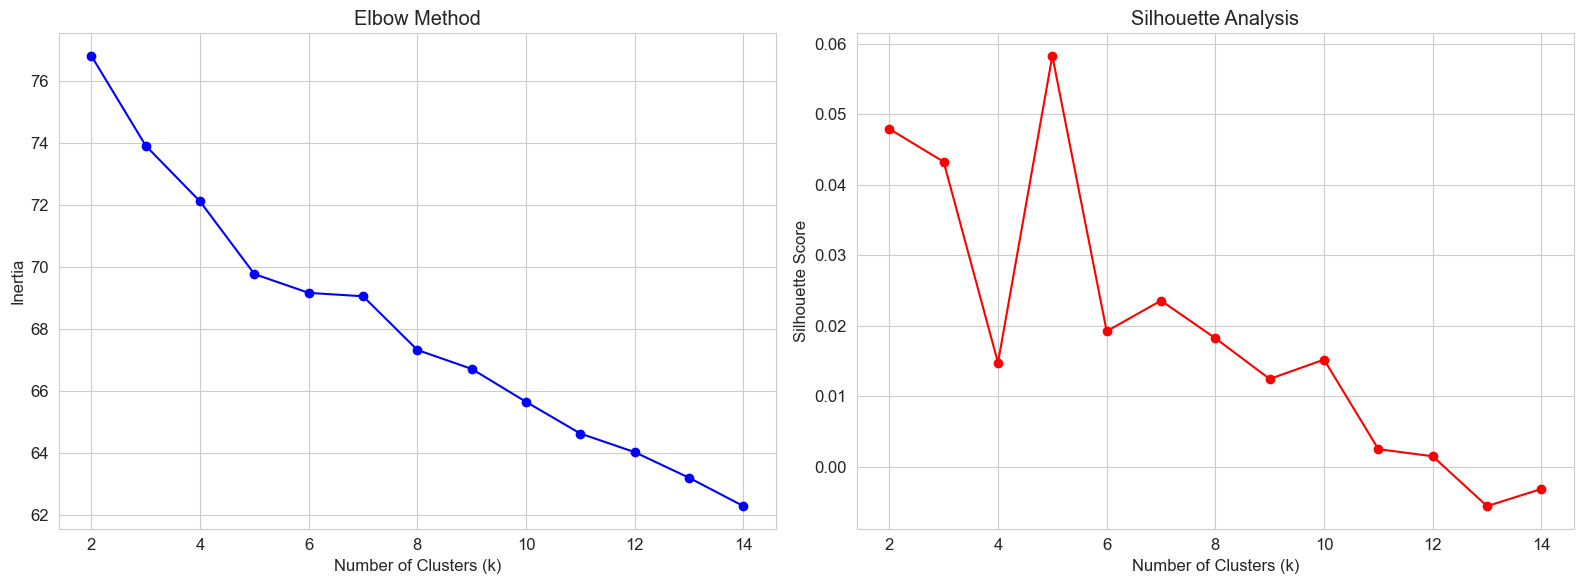

🏆 Optimal K determined: 5


In [32]:

# Determine Optimal K using Elbow Method and Silhouette Analysis
inertia = []
silhouette_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

# Automatically select K with max silhouette score
OPTIMAL_K = K_range[np.argmax(silhouette_scores)]
print(f"🏆 Optimal K determined: {OPTIMAL_K}")


### 4.2 Model Training & Comparison


📊 Clustering Method Comparison:
                    Method  Silhouette  Calinski-Harabasz  Davies-Bouldin  \
0                  K-Means    0.058290           6.301923        3.215323   
1      Hierarchical (Ward)    0.049855           5.916414        3.370147   
2  Hierarchical (Complete)    0.021828           3.995573        3.809355   

   Time (s)  
0  0.029721  
1  0.007291  
2  0.006486  


/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

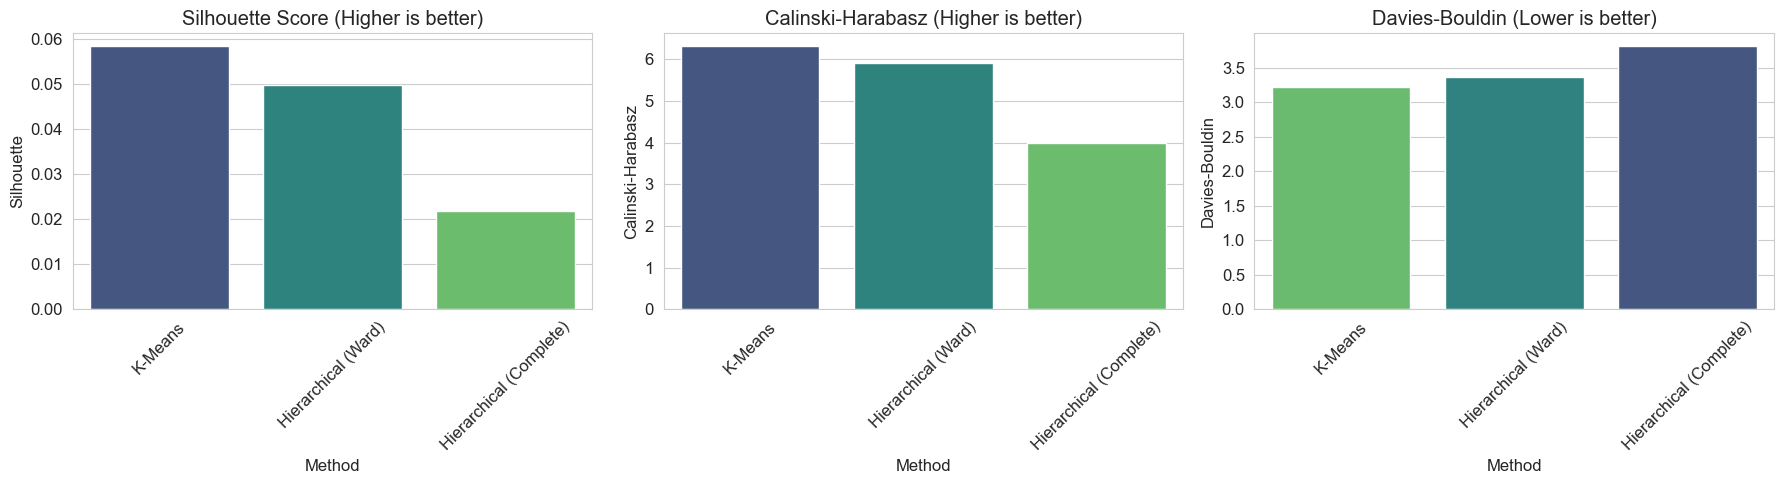

In [33]:

# Initialize metrics storage
metrics_data = []

def record_metrics(name, labels, time_taken):
    s_score = silhouette_score(embeddings, labels)
    ch_score = calinski_harabasz_score(embeddings, labels)
    db_score = davies_bouldin_score(embeddings, labels)
    metrics_data.append({
        'Method': name,
        'Silhouette': s_score,
        'Calinski-Harabasz': ch_score,
        'Davies-Bouldin': db_score,
        'Time (s)': time_taken
    })

# 1. K-Means
start = time.time()
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings)
record_metrics('K-Means', kmeans_labels, time.time() - start)

# 2. Hierarchical (Ward)
start = time.time()
ward = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
ward_labels = ward.fit_predict(embeddings)
record_metrics('Hierarchical (Ward)', ward_labels, time.time() - start)

# 3. Hierarchical (Complete)
start = time.time()
complete = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='complete')
complete_labels = complete.fit_predict(embeddings)
record_metrics('Hierarchical (Complete)', complete_labels, time.time() - start)

# Create DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Display Comparison
print("\n📊 Clustering Method Comparison:")
print(df_metrics.sort_values(by='Silhouette', ascending=False))

# Visualize Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Method', y='Silhouette', data=df_metrics, ax=axes[0], palette='viridis')
axes[0].set_title('Silhouette Score (Higher is better)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Method', y='Calinski-Harabasz', data=df_metrics, ax=axes[1], palette='viridis')
axes[1].set_title('Calinski-Harabasz (Higher is better)')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x='Method', y='Davies-Bouldin', data=df_metrics, ax=axes[2], palette='viridis_r')
axes[2].set_title('Davies-Bouldin (Lower is better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5️⃣ Visualization

### 5.1 Hierarchical Dendrogram

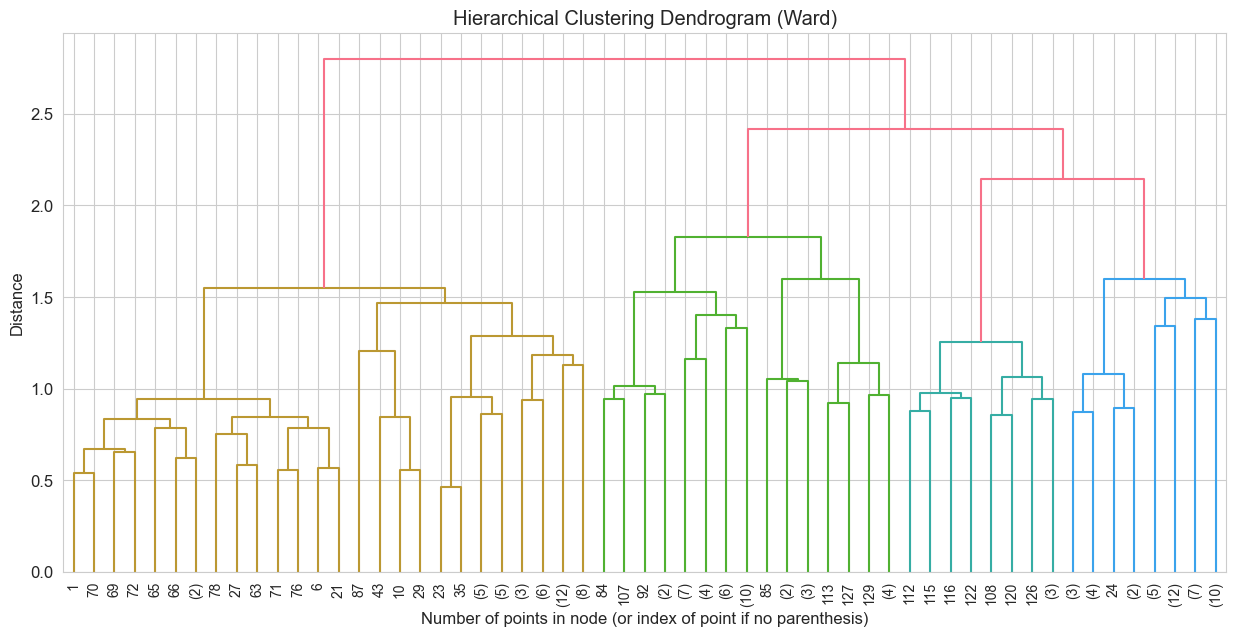

In [34]:

plt.figure(figsize=(15, 7))
plt.title(f"Hierarchical Clustering Dendrogram (Ward)")
linkage_matrix = linkage(embeddings, method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5, leaf_rotation=90., leaf_font_size=10.)
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


### 5.2 t-SNE Projection

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/u

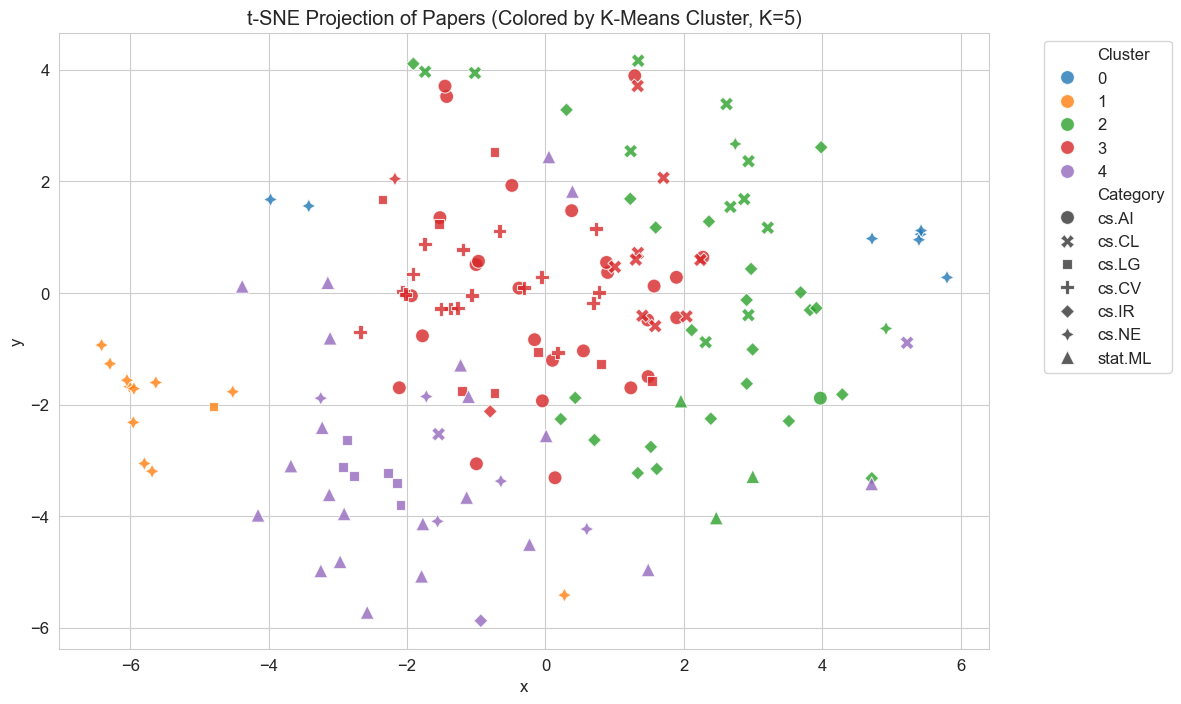

In [35]:

# t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(embeddings)

# Create plotting dataframe
df_vis = df_papers.copy()
df_vis['x'] = vis_dims[:, 0]
df_vis['y'] = vis_dims[:, 1]
df_vis['Cluster'] = kmeans_labels
df_vis['Category'] = df_vis['primary_category']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_vis, x='x', y='y', hue='Cluster', style='Category', 
    palette='tab10', s=100, alpha=0.8
)
plt.title(f"t-SNE Projection of Papers (Colored by K-Means Cluster, K={OPTIMAL_K})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## 6️⃣ Automated Insights

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_cluster_keywords(texts, top_n=10):
    """
    Generates top_terms by recalculating TF-IDF for the specific cluster text.
    This works regardless of whether you used Qdrant or TF-IDF for clustering.
    """
    if not texts:
        return []
    
    # 1. Create a mini-vectorizer just for this cluster's content
    tfidf = TfidfVectorizer(stop_words='english', max_features=100)
    
    try:
        tfidf_matrix = tfidf.fit_transform(texts)
        feature_names = tfidf.get_feature_names_out()
        
        # 2. Calculate average score per word to find the "centroid" of meaning
        avg_scores = np.mean(tfidf_matrix.toarray(), axis=0)
        
        # 3. Get top_indices and top_terms relative to this cluster
        top_indices = avg_scores.argsort()[::-1][:top_n]
        top_terms = [feature_names[ind] for ind in top_indices]
        
        return top_terms
        
    except ValueError:
        return []

print("📊 CLUSTER COMPOSITION ANALYSIS")
print("=" * 60)

# Add cluster labels to dataframe for easier analysis
df_papers['cluster'] = kmeans_labels

for i in range(OPTIMAL_K):
    cluster_papers = df_papers[df_papers['cluster'] == i]
    papers_count = len(cluster_papers)
    
    if papers_count > 0:
        # Get abstracts for keywords
        cluster_abstracts = cluster_papers['paper_abstract'].dropna().tolist()
        keywords = get_cluster_keywords(cluster_abstracts)
        
        # Get category distribution
        cat_dist = cluster_papers['primary_category'].value_counts().head(3).to_dict()
        
        print(f"\n🔹 Cluster {i}: {papers_count} papers")
        print(f"   Top Categories: {cat_dist}")
        print(f"   Keywords: {', '.join(keywords)}")
        
        print(f"   Sample Papers:")
        for title in cluster_papers['title'].head(3):
            print(f"      • {title[:80]}...")
    else:
        print(f"\n🔹 Cluster {i} (Empty)")

📊 CLUSTER COMPOSITION ANALYSIS

🔹 Cluster 0: 7 papers
   Top Categories: {'cs.NE': 7}
   Keywords: optimization, objective, data, large, design, operator, multi, evolattice, surrogate, meta
   Sample Papers:
      • Routing-Led Evolutionary Algorithm for Large-Scale Multi-Objective VNF Placement...
      • Offline Multi-Task Multi-Objective Data-Driven Evolutionary Algorithm with Langu...
      • EvoLattice: Persistent Internal-Population Evolution through Multi-Alternative Q...

🔹 Cluster 1: 12 papers
   Top Categories: {'cs.NE': 11, 'cs.LG': 1}
   Keywords: neural, memory, networks, snns, inference, learning, network, energy, hardware, spiking
   Sample Papers:
      • On the Universal Representation Property of Spiking Neural Networks...
      • Hypernetworks That Evolve Themselves...
      • Improving Low-Latency Learning Performance in Spiking Neural Networks via a Chan...

🔹 Cluster 2: 41 papers
   Top Categories: {'cs.IR': 24, 'cs.CL': 11, 'stat.ML': 3}
   Keywords: models, mode

In [37]:
# Create df_queries from the NESTED evaluation results structure
if 'test_cases' in results:
    query_data = []
    for tc in results['test_cases']:
        paper_title = tc.get('paper_title', '')
        paper_id = tc.get('paper_id', '')
        
        # The question_results is a LIST of questions for each paper
        for qr in tc.get('question_results', []):
            # Check if answer_metrics and meets_thresholds exist
            answer_metrics = qr.get('answer_metrics', {})
            meets_thresholds = qr.get('meets_thresholds', {})
            
            # Determine if "passed" based on all thresholds being met
            passed = all(meets_thresholds.values()) if meets_thresholds else False
            
            query_data.append({
                'paper_id': paper_id,
                'paper_title': paper_title,
                'query': qr.get('question', ''),
                'expected_answer': qr.get('expected_answer_type', ''),  # No ground truth answer exists
                'retrieved_answer': qr.get('answer', ''),  # This is the generated answer
                'precision': answer_metrics.get('answer_relevancy', 0.0),
                'recall': answer_metrics.get('completeness', 0.0),
                'f1_score': answer_metrics.get('overall_score', 0.0),
                'faithfulness': answer_metrics.get('faithfulness', 0.0),
                'passed': passed
            })
    
    df_queries = pd.DataFrame(query_data)
    print(f"📊 Created df_queries with {len(df_queries)} queries")
else:
    df_queries = pd.DataFrame()
    print("⚠️ No evaluation results found - df_queries is empty")

📊 Created df_queries with 25 queries


In [38]:
# 🔍 3. FAILURE ANALYSIS - Expected vs Generated Answers
print("🔍 FAILURE ANALYSIS - Expected vs Generated Answers")
print("=" * 60)

# Sample a few failed queries for detailed inspection
if len(df_queries) > 0:
    failed_df = df_queries[df_queries['passed'] == False]
    
    # Show first 5 failed queries in detail
    sample_size = min(5, len(failed_df))
    print(f"\n📋 Detailed Analysis of {sample_size} Failed Queries:\n")
    
    for idx, row in failed_df.head(sample_size).iterrows():
        print(f"{'='*60}")
        print(f"📄 Paper: {row['paper_title'][:60]}...")
        print(f"❓ Query: {row['query'][:80]}...")
        print(f"\n   Expected Answer:")
        expected = row['expected_answer'] if row['expected_answer'] else "(empty)"
        print(f"      {expected[:200]}...")
        print(f"\n   Generated Answer:")
        retrieved = row['retrieved_answer'] if row['retrieved_answer'] else "(empty)"
        print(f"      {retrieved[:200]}...")
        print(f"\n   Metrics: Precision={row['precision']:.2f}, Recall={row['recall']:.2f}, F1={row['f1_score']:.2f}")
        print()
    
    # Summary statistics
    print(f"\n{'='*60}")
    print("📊 FAILURE SUMMARY:")
    print(f"   Total Queries: {len(df_queries)}")
    print(f"   Failed: {len(failed_df)} ({len(failed_df)/len(df_queries)*100:.0f}%)")
    print(f"   Avg Precision: {df_queries['precision'].mean():.2f}")
    print(f"   Avg Recall: {df_queries['recall'].mean():.2f}")
    print(f"   Avg F1: {df_queries['f1_score'].mean():.2f}")
    
    # Check if answers are empty
    empty_expected = (failed_df['expected_answer'] == '').sum() + failed_df['expected_answer'].isna().sum()
    empty_retrieved = (failed_df['retrieved_answer'] == '').sum() + failed_df['retrieved_answer'].isna().sum()
    
    if empty_expected > 0 or empty_retrieved > 0:
        print(f"\n⚠️ Potential Issues:")
        if empty_expected > 0:
            print(f"   - {empty_expected} queries have empty expected answers")
        if empty_retrieved > 0:
            print(f"   - {empty_retrieved} queries have empty generated answers")
else:
    print("⚠️ No query data available for analysis")

🔍 FAILURE ANALYSIS - Expected vs Generated Answers

📋 Detailed Analysis of 5 Failed Queries:

📄 Paper: CauSTream: Causal Spatio-Temporal Representation Learning fo...
❓ Query: Describe the approach taken in this paper....

   Expected Answer:
      methodology...

   Generated Answer:
      The paper "CauSTream: Causal Spatio-Temporal Representation Learning for Streamflow Forecasting" by Shu Wan et al. focuses on streamflow forecasting, which is essential for water resource management. ...

   Metrics: Precision=0.80, Recall=0.80, F1=0.87

📄 Paper: CauSTream: Causal Spatio-Temporal Representation Learning fo...
❓ Query: What metrics were used to measure performance?...

   Expected Answer:
      results...

   Generated Answer:
      The documents do not provide specific details on the metrics used to measure performance. However, Document 3 mentions that more details on metrics can be found in supplementary material, indicating t...

   Metrics: Precision=0.80, Recall=0.80, F1=0.67



/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/u


✅ PCA 2D variance explained: 13.1%


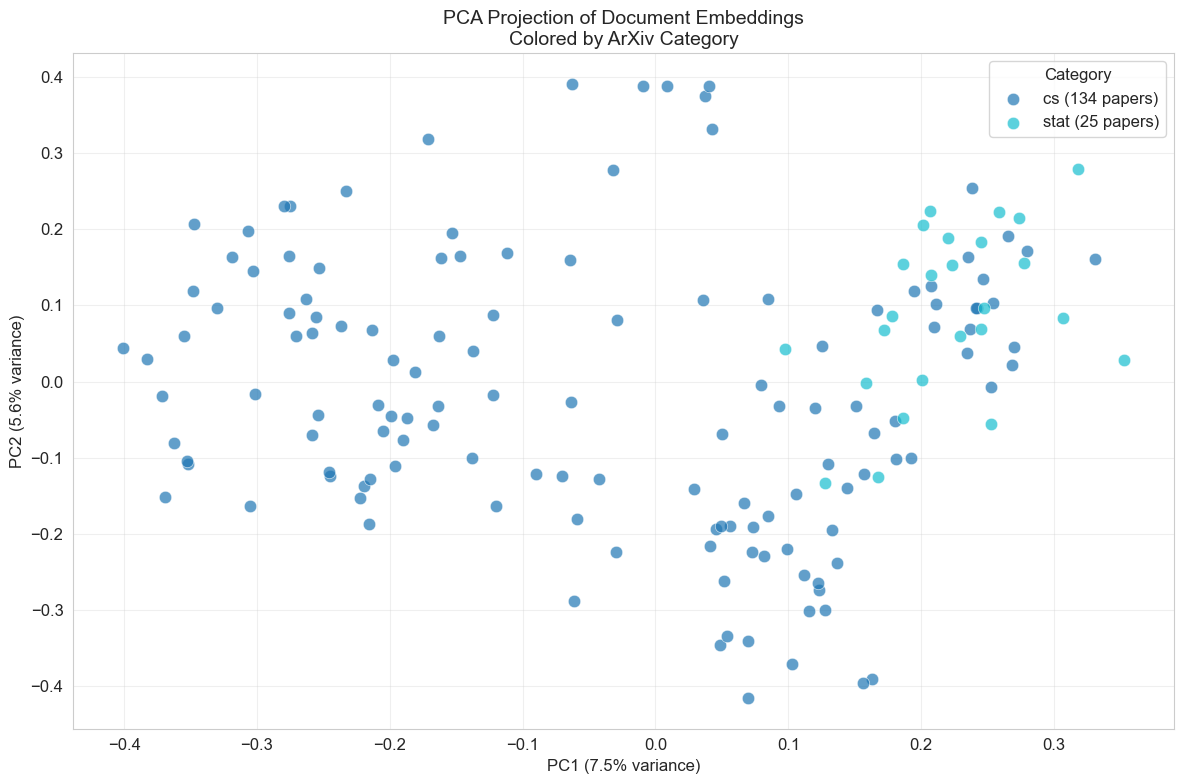

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
# Normalize embeddings
embeddings_norm = normalize(embeddings)
# PCA to 2D
pca_2d = PCA(n_components=2, random_state=42)
embeddings_pca_2d = pca_2d.fit_transform(embeddings_norm)
print(f"\n✅ PCA 2D variance explained: {pca_2d.explained_variance_ratio_.sum():.1%}")
# Plot
fig, ax = plt.subplots(figsize=(12, 8))
unique_categories = df_papers['main_category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_categories)))
color_map = dict(zip(unique_categories, colors))
for cat in unique_categories:
    mask = df_papers['main_category'] == cat
    ax.scatter(
        embeddings_pca_2d[mask, 0], 
        embeddings_pca_2d[mask, 1],
        c=[color_map[cat]],
        label=f"{cat} ({mask.sum()} papers)",
        s=80, alpha=0.7, edgecolors='white', linewidth=0.5
    )
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Projection of Document Embeddings\nColored by ArXiv Category', fontsize=14)
ax.legend(title='Category', loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/goodwiinz/development/RAG_system/.venv/lib/python3.13/site-packages/sklearn/u

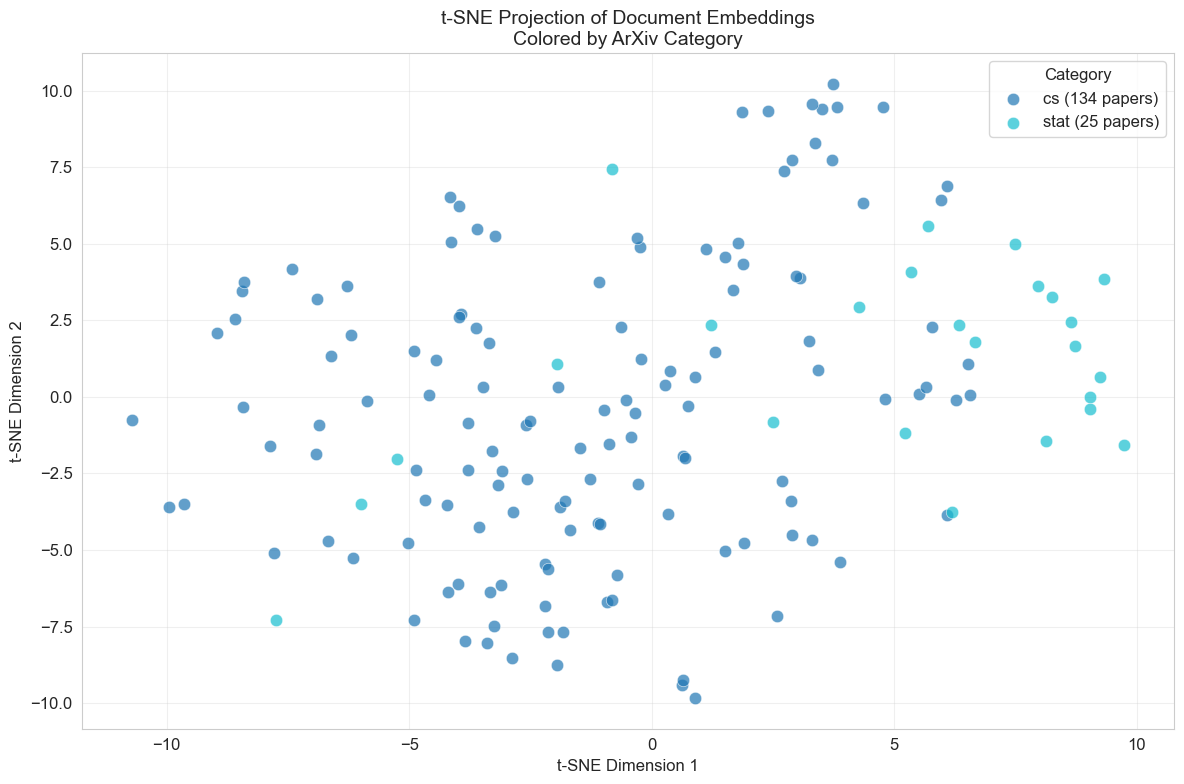

In [41]:
# t-SNE on PCA-reduced data
from sklearn.manifold import TSNE

# PCA to 50D first (speeds up t-SNE)
pca_50d = PCA(n_components=min(50, embeddings.shape[1]), random_state=42)
embeddings_pca_50d = pca_50d.fit_transform(embeddings_norm)

perplexity = min(30, len(embeddings) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
embeddings_tsne_2d = tsne.fit_transform(embeddings_pca_50d)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

for cat in unique_categories:
    mask = df_papers['main_category'] == cat
    ax.scatter(
        embeddings_tsne_2d[mask, 0], 
        embeddings_tsne_2d[mask, 1],
        c=[color_map[cat]],
        label=f"{cat} ({mask.sum()} papers)",
        s=80, alpha=0.7, edgecolors='white', linewidth=0.5
    )

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE Projection of Document Embeddings\nColored by ArXiv Category', fontsize=14)
ax.legend(title='Category', loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Cluster-Category Alignment:
   Adjusted Rand Index: 0.134
   Normalized Mutual Info: 0.238


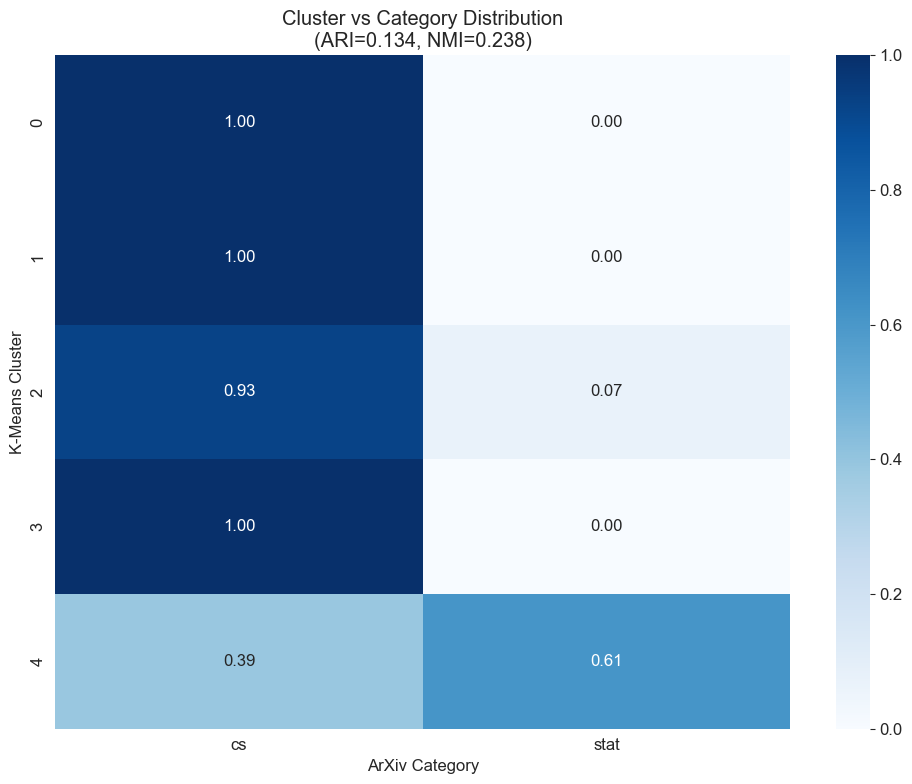

In [42]:
# Compare clusters with categories
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

df_papers['cluster'] = kmeans.labels_

# Alignment metrics
le = LabelEncoder()
category_labels = le.fit_transform(df_papers['main_category'])
ari = adjusted_rand_score(category_labels, kmeans.labels_)
nmi = normalized_mutual_info_score(category_labels, kmeans.labels_)

print(f"📊 Cluster-Category Alignment:")
print(f"   Adjusted Rand Index: {ari:.3f}")
print(f"   Normalized Mutual Info: {nmi:.3f}")

# Heatmap
confusion = pd.crosstab(df_papers['cluster'], df_papers['main_category'], normalize='index')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(confusion, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_xlabel('ArXiv Category')
ax.set_ylabel('K-Means Cluster')
ax.set_title(f'Cluster vs Category Distribution\n(ARI={ari:.3f}, NMI={nmi:.3f})')
plt.tight_layout()
plt.savefig('cluster_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()